🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...
1. Đang tải và ép cân dữ liệu Calendar...
2. Đang tải dữ liệu Sales...
3. Đang Melt (kéo giãn) dữ liệu Sales...
4. Đang Merge Sales với Calendar...

-> Đang xử lý Outliers (IQR) và Zeroes...
5. Ép cân lần cuối cho DataFrame tổng...
-> Đang load dữ liệu Giá (sell_prices.csv)...
-> Đang hợp nhất và tính toán độ co giãn giá...
-> Đang xử lý Sự kiện lễ tết (Calendar Events)...
-> Đang tạo Đặc trưng Thời gian (Time Features)...

🎯 Đang phân tích riêng sản phẩm: 1437 tại 0

⏳ Đang chạy Grid Search để tìm tham số Tối ưu nhất...
✅ Đã tìm thấy tham số tối ưu (Validation RMSE: 1.0556)
-> Learning Rate: 0.05 | Num Leaves: 15 | Tweedie Power: 1.1

🧠 Đang huấn luyện mô hình chốt sổ...

📊 BÁO CÁO CHUNG CUỘC - MÃ 1437 📊
SAI SỐ MÔ HÌNH: MAE = 0.91 | RMSE = 1.31
CHIẾN LƯỢC NHẬP KHO: ROP = 0 | EOQ = 10
TỔNG CHI PHÍ DỰ KIẾN: $126.50


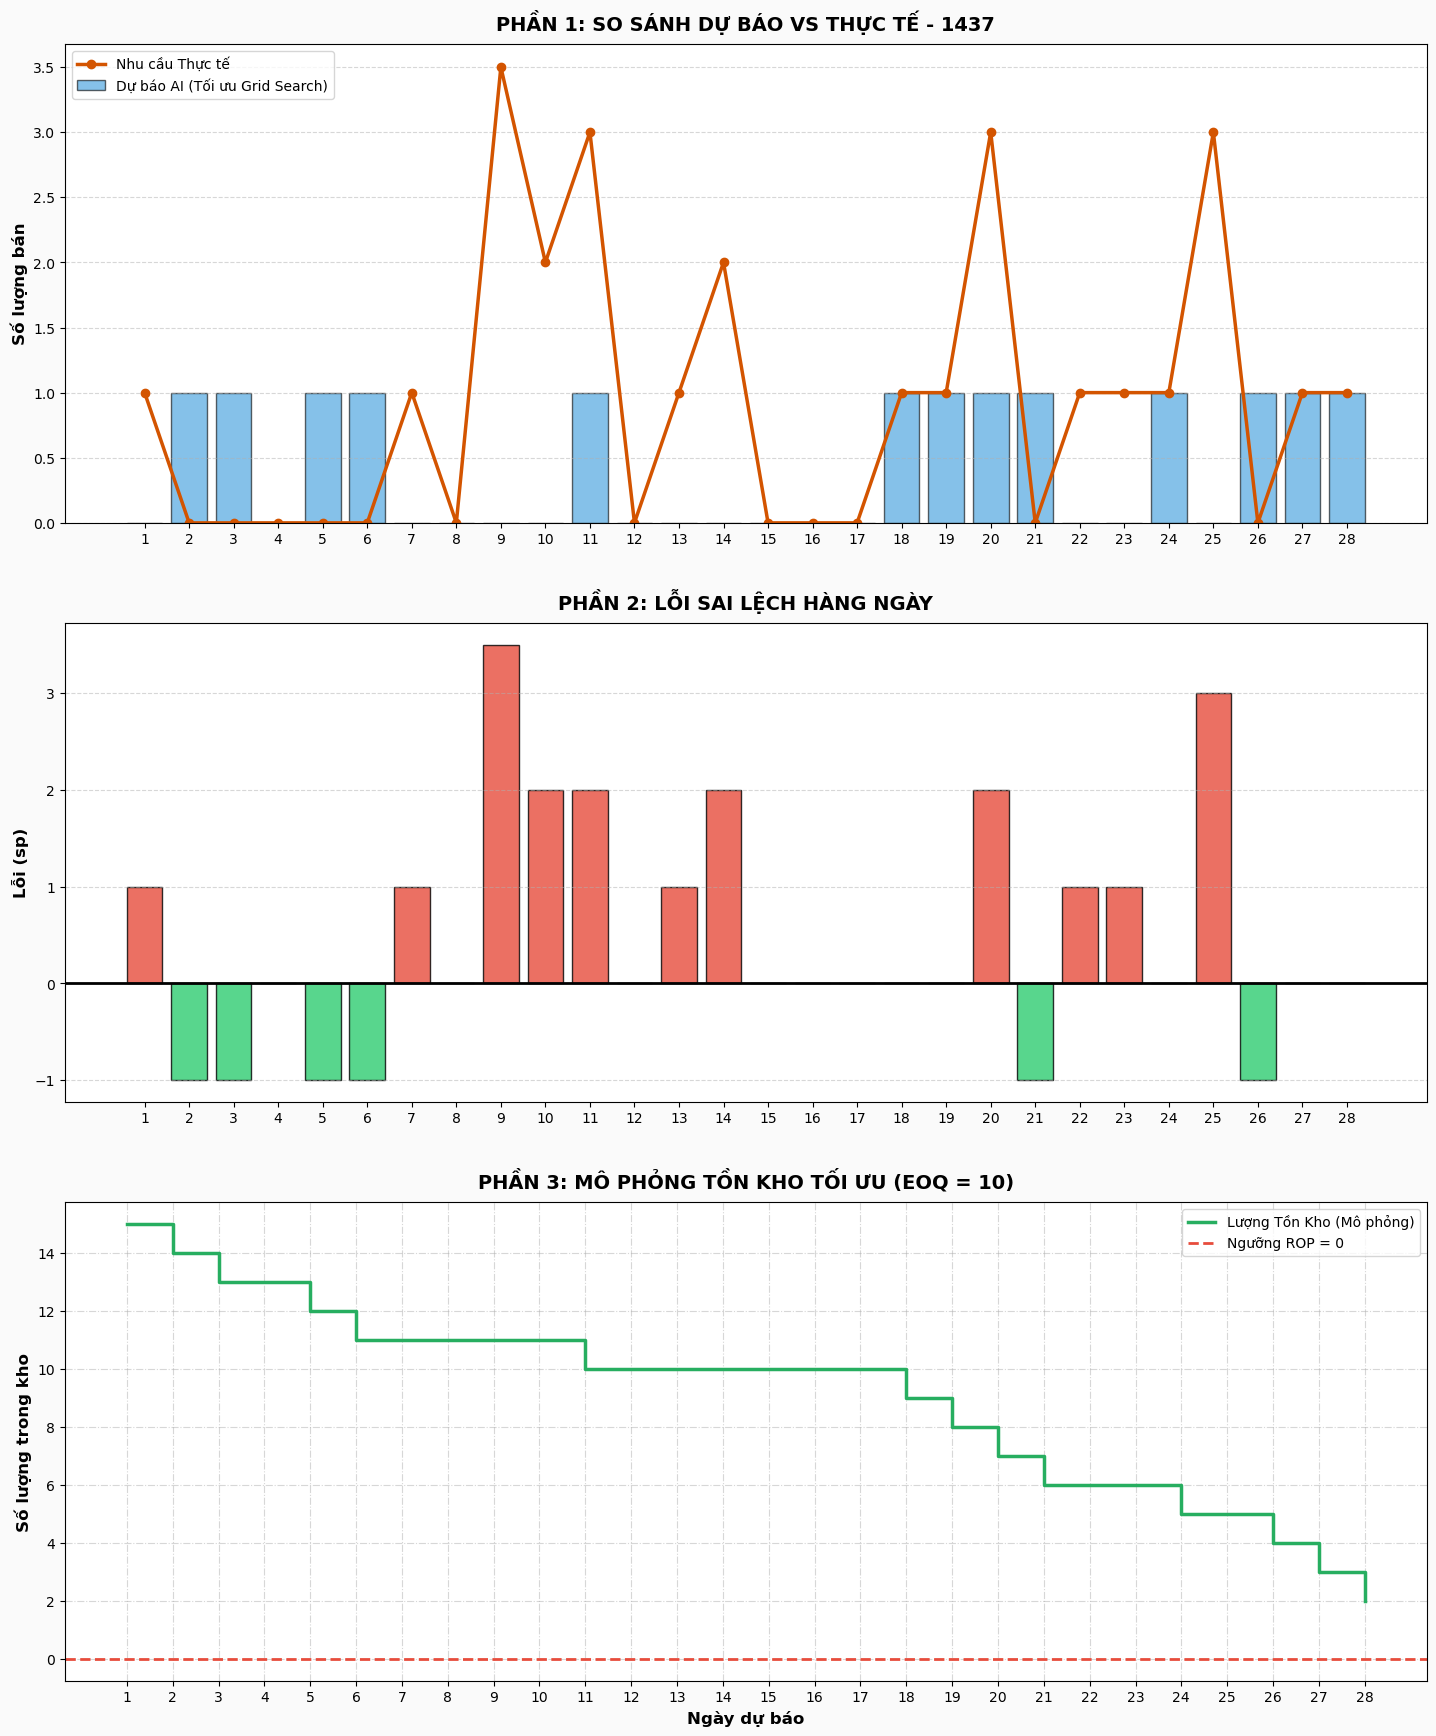

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Trỏ đường dẫn để gọi module từ thư mục src
sys.path.append(os.path.abspath('../src'))
from dataPreprocessing import load_and_preprocess_raw
from featureEngineering import generate_all_features, create_lag_features_for_item

RAW_DIR = '../dataset/raw/'

# ==========================================
# BƯỚC 1 & 2: TIỀN XỬ LÝ (Chạy siêu tốc)
# ==========================================
print("🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...")
# Lấy 10000 dòng là đủ xài cho Local Model
df_master = load_and_preprocess_raw(RAW_DIR, nrows=10000)
df_featured = generate_all_features(df_master, RAW_DIR)

# ==========================================
# BƯỚC 4: CHUẨN BỊ DỮ LIỆU LOCAL (CHO 1 MÃ DUY NHẤT)
# ==========================================
sample_item = df_featured['item_id'].iloc[0]
sample_store = df_featured['store_id'].iloc[0]
print(f"\n🎯 Đang phân tích riêng sản phẩm: {sample_item} tại {sample_store}")

df_item = df_featured[(df_featured['item_id'] == sample_item) & (df_featured['store_id'] == sample_store)].copy()
df_item = create_lag_features_for_item(df_item)

features = [
    'day', 'is_weekend', 'sell_price', 'price_discount', 'price_momentum',
    'event_name_1', 'lag_7', 'lag_14', 'rolling_mean_7'
]
target = 'demand'

# Tách 28 ngày cuối làm Test
max_date = df_item['date'].max()
split_date = max_date - pd.Timedelta(days=28)

train_data_history = df_item[df_item['date'] <= split_date]
test_data_actuals = df_item[df_item['date'] > split_date]

# ==========================================
# BƯỚC 5: TỐI ƯU THAM SỐ (GRID SEARCH) & TRAIN MODEL
# ==========================================
print("\n⏳ Đang chạy Grid Search để tìm tham số Tối ưu nhất...")

# Tách Validation set (28 ngày) từ tập Train để test thông số
train_size = len(train_data_history) - 28
X_tr, y_tr = train_data_history[features].iloc[:train_size], train_data_history[target].iloc[:train_size]
X_val, y_val = train_data_history[features].iloc[train_size:], train_data_history[target].iloc[train_size:]

lgb_train = lgb.Dataset(X_tr, y_tr, categorical_feature=['event_name_1'])
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train, categorical_feature=['event_name_1'])

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'tweedie_variance_power': [1.1, 1.3, 1.5]
}

best_rmse = float('inf')
best_params = None

for lr in param_grid['learning_rate']:
    for nl in param_grid['num_leaves']:
        for tvp in param_grid['tweedie_variance_power']:
            current_params = {
                'objective': 'tweedie',
                'metric': 'rmse',
                'learning_rate': lr,
                'num_leaves': nl,
                'tweedie_variance_power': tvp,
                'verbose': -1,
                'force_col_wise': True
            }
            temp_model = lgb.train(
                current_params, 
                lgb_train, 
                num_boost_round=150, 
                valid_sets=[lgb_val],
                callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
            )
            preds = temp_model.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, preds))
            if rmse < best_rmse:
                best_rmse, best_params = rmse, current_params

print(f"✅ Đã tìm thấy tham số tối ưu (Validation RMSE: {best_rmse:.4f})")
print(f"-> Learning Rate: {best_params['learning_rate']} | Num Leaves: {best_params['num_leaves']} | Tweedie Power: {best_params['tweedie_variance_power']}")

print("\n🧠 Đang huấn luyện mô hình chốt sổ...")
X_train_final, y_train_final = train_data_history[features], train_data_history[target]
final_train_set = lgb.Dataset(X_train_final, y_train_final, categorical_feature=['event_name_1'])
model = lgb.train(best_params, final_train_set, num_boost_round=150) 

# ==========================================
# BƯỚC 5B: DỰ BÁO TRÊN TẬP TEST
# ==========================================
X_test = test_data_actuals[features]
y_actual = test_data_actuals[target].values

daily_demand_forecast_ai = model.predict(X_test)
# Làm tròn về số nguyên
daily_demand_forecast = np.round(daily_demand_forecast_ai).astype(int)

# ==========================================
# BƯỚC 6: MÔ PHỎNG TỒN KHO & EOQ/ROP
# ==========================================
LEAD_TIME = 3            
ORDERING_COST = 50.0     
HOLDING_COST = 0.5       
STOCKOUT_COST = 5.0      
INITIAL_INVENTORY = 15   

def simulate_inventory(demand_array, ROP, Q):
    inventory = INITIAL_INVENTORY
    total_cost = 0
    days_to_arrival = 0
    order_placed = False
    inventory_history = []
    for demand in demand_array:
        if order_placed and days_to_arrival == 0:
            inventory += Q
            order_placed = False
        if inventory >= demand:
            inventory -= demand
        else:
            total_cost += (demand - inventory) * STOCKOUT_COST
            inventory = 0
        total_cost += inventory * HOLDING_COST
        if inventory <= ROP and not order_placed:
            total_cost += ORDERING_COST
            order_placed = True
            days_to_arrival = LEAD_TIME
        if order_placed:
            days_to_arrival -= 1
        inventory_history.append(inventory)
    return total_cost, inventory_history

best_cost, best_ROP, best_Q = float('inf'), 0, 0
best_history = []

for rop in range(0, 50, 2):
    for q in range(10, 150, 5):
        cost, history = simulate_inventory(daily_demand_forecast, rop, q)
        if cost < best_cost:
            best_cost, best_ROP, best_Q, best_history = cost, rop, q, history

# ==========================================
# BÁO CÁO & VẼ BIỂU ĐỒ 3 TẦNG
# ==========================================
mae = mean_absolute_error(y_actual, daily_demand_forecast)
rmse = np.sqrt(mean_squared_error(y_actual, daily_demand_forecast))
print("\n" + "="*60)
print(f"📊 BÁO CÁO CHUNG CUỘC - MÃ {sample_item} 📊")
print("="*60)
print(f"SAI SỐ MÔ HÌNH: MAE = {mae:,.2f} | RMSE = {rmse:,.2f}")
print(f"CHIẾN LƯỢC NHẬP KHO: ROP = {best_ROP} | EOQ = {best_Q}")
print(f"TỔNG CHI PHÍ DỰ KIẾN: ${best_cost:,.2f}")

daily_errors = y_actual - daily_demand_forecast

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 18), facecolor='#FAFAFA')

ax1.bar(range(1, 29), daily_demand_forecast, color='#3498DB', edgecolor='black', alpha=0.6, label='Dự báo AI (Tối ưu Grid Search)')
ax1.plot(range(1, 29), y_actual, color='#D35400', marker='o', linewidth=2.5, label='Nhu cầu Thực tế')
ax1.set_title(f"PHẦN 1: SO SÁNH DỰ BÁO VS THỰC TẾ - {sample_item}", fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel("Số lượng bán", fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, 29))
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

colors = ['#E74C3C' if e > 0 else '#2ECC71' for e in daily_errors]
ax2.bar(range(1, 29), daily_errors, color=colors, edgecolor='black', alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax2.set_title(f"PHẦN 2: LỖI SAI LỆCH HÀNG NGÀY", fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel("Lỗi (sp)", fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, 29))
ax2.grid(axis='y', linestyle='--', alpha=0.5)

ax3.step(range(1, 29), best_history, where='post', color='#27AE60', linewidth=2.5, label='Lượng Tồn Kho (Mô phỏng)')
ax3.axhline(y=best_ROP, color='#E74C3C', linestyle='--', linewidth=2, label=f'Ngưỡng ROP = {best_ROP}')
ax3.set_title(f"PHẦN 3: MÔ PHỎNG TỒN KHO TỐI ƯU (EOQ = {best_Q})", fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel("Ngày dự báo", fontsize=12, fontweight='bold')
ax3.set_ylabel("Số lượng trong kho", fontsize=12, fontweight='bold')
ax3.set_xticks(range(1, 29))
ax3.grid(True, linestyle='-.', alpha=0.5)
ax3.legend(loc='upper right')

plt.tight_layout(pad=3.0) 
os.makedirs('../docs/images', exist_ok=True)
plt.savefig('../docs/images/bieu_do_local_optimized.png', dpi=300, bbox_inches='tight')
plt.show()